In [1]:
import torch
import torch.nn as nn

In [ ]:
network = nn.Sequential(
    nn.Linear(2,1000),
    nn.Linear(1000 ,100000),
    nn.Linear(100000 , 2)
)
total=0
for param in network.parameters():
    total+=param.numel()


# Activations

In [ ]:
import torch.nn as nn

net = nn.Sequential(
    nn.Linear(4, 10),
    nn.ReLU(),
    nn.Linear(10, 8),
    nn.PReLU(num_parameters=1, init=0.2),  # correct usage
    nn.Linear(8, 1),
    nn.Sigmoid()  # correct
)

tensor = torch.full((1,4),1, dtype=torch.float)
# tensor
net(tensor)
# nn.Linear(10, 8)
# 🔹 Step 1: Output of Linear
# nn.Linear(10, 8)

# 👉 Produces:

# [x1, x2, x3, x4, x5, x6, x7, x8]

# → 8 neurons (features)

# 🔥 Case 1: nn.PReLU(1)
# nn.PReLU(1)

# 👉 Only ONE learnable parameter a

# So:

# [a*x1, a*x2, a*x3, ..., a*x8]

# 👉 All neurons share the same slope

# ✔ Behavior
# Simpler
# Less flexible
# Fewer parameters (only 1)

tensor([[0.5472]], grad_fn=<SigmoidBackward0>)

# LOSS FUNCTIONS

# 🔥 Loss Functions in PyTorch

Loss functions (also called criteria) measure how wrong a model’s predictions are.  
They are used to compute error so the optimizer can update the model.

---

# 🔹 1. CrossEntropyLoss (MOST IMPORTANT 🔥)

```python
nn.CrossEntropyLoss()
👉 Used for:
Multi-class classification (e.g., MNIST digits 0–9)
👉 Input format:
Raw logits (NO softmax needed)
Example:
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(outputs, labels)
🔹 2. BCELoss (Binary Cross Entropy)
nn.BCELoss()
👉 Used for:
Binary classification (0 or 1)
⚠️ Requires sigmoid before loss:
output = torch.sigmoid(logits)
loss = nn.BCELoss()(output, labels)
🔥 3. BCEWithLogitsLoss (BEST for binary classification)
nn.BCEWithLogitsLoss()
👉 Used for:
Binary classification (recommended)
👉 Why better?
Combines sigmoid + loss internally (more stable)
loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(logits, labels)
🔹 4. MSELoss (Mean Squared Error)
nn.MSELoss()
👉 Used for:
Regression problems
loss = nn.MSELoss()(pred, target)
🔹 5. L1Loss (Mean Absolute Error)
nn.L1Loss()
👉 Used for:
Regression (less sensitive to outliers)
🔹 6. KLDivLoss (Knowledge Distillation 🔥)
nn.KLDivLoss()
👉 Used for:
Knowledge distillation (teacher → student)
⚠️ Input format:
Student = log_softmax
Teacher = softmax
loss = nn.KLDivLoss()(student_log_probs, teacher_probs)
🔹 7. NLLLoss (Negative Log Likelihood)
nn.NLLLoss()
👉 Used with:
log_softmax + NLLLoss


In [ ]:
import torch.nn.functional as f

In [ ]:
f.one_hot(torch.tensor(0) , num_classes=3)
# F.one_hot() converts a class number into a vector form where only one position is 1 and the rest are 0.
# dog = 0 , cat =1 , crow =2
#after hot encdoing dog  [1,0,0] , cat:[0,1,0] , crow : [0,0,1]
d = {"cat":0 ,"dog": 1,"crow":2}
t = []
for i in range(len(d)):
  t.append(f.one_hot(torch.tensor(i)  , num_classes=len(d)))



In [ ]:
t , # hot enocded labels

([tensor([1, 0, 0]), tensor([0, 1, 0]), tensor([0, 0, 1])],)

In [ ]:
network =  nn.Sequential(
    nn.Linear(8 ,32),
    nn.ReLU(),
    nn.Linear(32 ,16),
    nn.ReLU(),
    nn.Linear(16 , 8),
    nn.ReLU(),
    nn.Linear(8,4),
    nn.ReLU(),
    nn.Linear(4,3),


)
labels = {
    "cat":0,
    "dog":1,
    "cat":0,
    "cat":0
}
data=torch.arange(1,33 , dtype=torch.float).reshape(4,8)

# ACCESSING WEIGHTS AND BIAS OF LAYERS

In [ ]:
model = nn.Sequential(nn.Linear(16, 8),
                      nn.Linear(8, 2)
                     )

# Access the weight of the first linear layer
weight_0 = model[0].weight
print("Weight of the first layer:", weight_0)

# Access the bias of the second linear layer
bias_1 = model[1].bias
print("Bias of the second layer:", bias_1)

Weight of the first layer: Parameter containing:
tensor([[-0.2445, -0.1500, -0.0469,  0.1593,  0.0850,  0.1779,  0.0831, -0.2128,
         -0.0623,  0.1422, -0.1739, -0.0281,  0.0873,  0.1960,  0.0997, -0.1676],
        [ 0.0693,  0.0633, -0.1445, -0.1366, -0.2009, -0.2383,  0.1428,  0.1315,
          0.0781, -0.0242,  0.1555,  0.0131,  0.1847,  0.1070, -0.1159,  0.2144],
        [ 0.0264,  0.1737, -0.1833,  0.0226,  0.0060,  0.2227, -0.0829, -0.0031,
          0.1601, -0.1595, -0.0956,  0.2408,  0.2062,  0.2431, -0.1835,  0.0320],
        [ 0.1877,  0.1047,  0.1060,  0.0403,  0.1202,  0.0442, -0.1599,  0.1671,
         -0.0401, -0.1458, -0.0183,  0.0854, -0.0175, -0.2052,  0.1682, -0.0460],
        [ 0.0820, -0.0510,  0.0908,  0.2269,  0.1237, -0.0621, -0.0978, -0.1296,
         -0.0594,  0.0138, -0.0142,  0.0521,  0.1661, -0.0315,  0.1647, -0.2150],
        [-0.0094, -0.0770, -0.2221, -0.0555,  0.2318,  0.2404, -0.2302,  0.1258,
          0.0356, -0.1635, -0.0855,  0.2008, -0.0086, -

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple model for demonstration
model = nn.Sequential(
    nn.Linear(16, 8),
    nn.Linear(8, 2)
)

# Define a dummy input and target
dummy_input = torch.randn(1, 16) # Batch size 1, 16 features
dummy_target = torch.tensor([0]) # Dummy target for classification (e.g., class 0)

# Define a loss function
criterion = nn.CrossEntropyLoss()

# Create the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.001)

# --- Training Step Demonstration ---

# 1. Zero the gradients
optimizer.zero_grad()

# 2. Forward pass
pred = model(dummy_input)

# 3. Calculate loss
loss = criterion(pred, dummy_target)

# 4. Backward pass (compute gradients)
loss.backward()

# 5. Update the model's parameters using the optimizer
optimizer.step()

print("Model parameters updated successfully using optimizer.step().")
# You can inspect the updated weights (e.g., model[0].weight) if needed
# print("Updated weight of the first layer:", model[0].weight)

Model parameters updated successfully using optimizer.step().


# BACK PROPOG

In [4]:
import torch
import torch.nn as nn

network = nn.Sequential(
    nn.Linear(4, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
    nn.Sigmoid()
)

# input (batch = 1, features = 4)
data = torch.randn(1, 4)

# target (same shape as output)
y = torch.tensor([[0.0]])

# forward pass
pred = network(data)

# loss function
loss_fn = nn.BCELoss()

loss = loss_fn(pred, y)

# backward pass
loss.backward()

# gradient of first layernetwork[0].weight.grad)
for layer in network:
    if isinstance(layer, nn.Linear):
        with torch.no_grad():
            layer.weight -= 0.1 * layer.weight.grad

# DATALOADER AND DATASET

- TensorDataset is a ready made dataset , u use when u already have dataset
- It is also made from Base Dataset class
- Use Dataset when:
    - Base class
    - Loading images/files
    - Doing preprocessing
    - cmplex data

In [5]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()

df = pd.DataFrame(iris.data , columns = iris.feature_names)
y =  pd.DataFrame(iris.target , columns=["y"])
from sklearn.model_selection import train_test_split
x1,x2,y1,y2 = train_test_split(df , y , test_size=0.12 , stratify=y)



In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset

train_dataset = TensorDataset(torch.tensor(x1.values).float() ,torch.tensor(y1.values.ravel()).float())

test_dataset = TensorDataset(torch.tensor(x2.values).float() ,torch.tensor(y2.values.ravel()).float())
train_loader = DataLoader(dataset=train_dataset , shuffle=True , batch_size=32 , drop_last=False)
test_loader = DataLoader(dataset=test_dataset , shuffle=True , batch_size=32 , drop_last=False)


In [ ]:
set(y1.values.ravel())


In [28]:
import torch.optim as optim
model = nn.Sequential(
    nn.Linear(x1.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)

optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_fn = nn.CrossEntropyLoss()

def train_loop(model, epochs, loader, optimizer):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for data, label in loader:
            # forward
            pred = model(data)

            # loss
            loss = loss_fn(pred, label.long())

            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        # print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")
train_loop(model=model, epochs=10, loader=train_loader, optimizer=optimizer)
def testing(model, loader):
    model.eval()
    acc = torchmetrics.F1Score("multiclass" ,num_classes=3)
    with torch.no_grad():
      for label , y in loader:
          pred = model(label)
          pred = torch.argmax(pred , dim=1)
          acc.update(pred , y)
    res = acc.compute().item()
    acc.reset()
    print(res)
testing(model , test_loader)

1.0


#LEARNING RATE AND MOMENTUM

# WEIGHT INIT


-  ReLU	  : Kaiming(He) [DEFAULT]
-  Sigmoid / Tanh	 :Xavier
-  Linear / none	 : Xavier

In [ ]:
import torch.nn.init as init

network = nn.Sequential(
    nn.Linear(x1.shape[1] , 32),
    nn.ReLU(),
    nn.Linear(32 , 16),
    nn.ReLU(),
    nn.Linear(16 , 3)
)

# HE normal
for layer in network:
  if isinstance(layer , nn.Linear):
     init.kaiming_normal_(layer.weight, nonlinearity="relu")
     init.zeros_(layer.bias)
# xavier
for layer in network:
  if isinstance(layer ,nn.Linear):
    init.xavier_uniform_(layer.weight)
    init.zeros_(layer.bias)
# uniform dist
for layer in network:
  if isinstance(layer ,nn.Linear):
    init.uniform_(layer.weight)
    init.zeros_(layer.bias)
# Save the model layers

torch.save(network.state_dict() ,"model.pth")

In [ ]:
# saving the layer wiehts and bias
torch.save(network[0].state_dict() ,"layer.pth")


In [ ]:
# loading the layer
lyer= torch.load("layer.pth")


odict_keys(['weight', 'bias'])

In [ ]:
#frezzing the layer
for name ,param in network.named_parameters():
  if "weight" in name:
    param.requires_grad = False

# Fine Tuning and Transfer learning

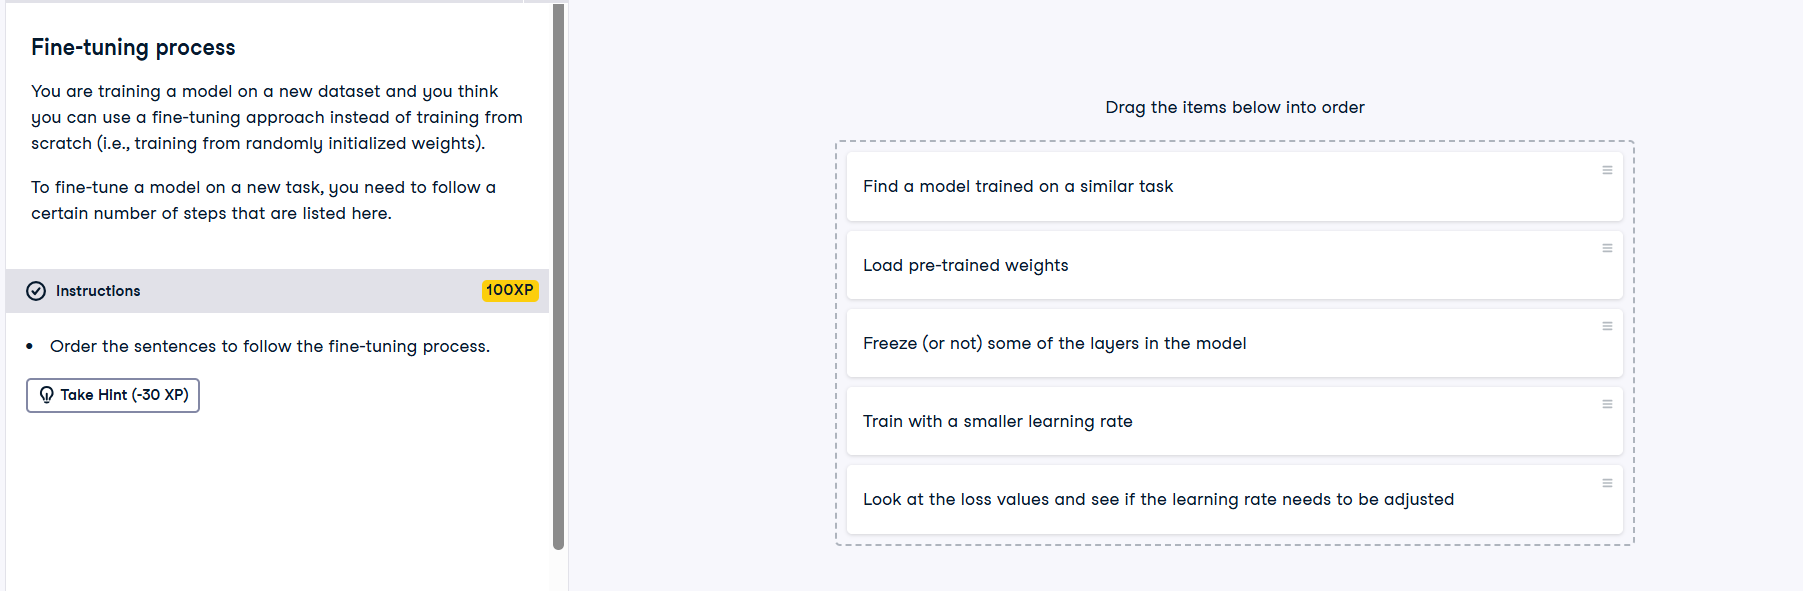

In [ ]:
!pip install torchmetrics

# Model Eval

In [29]:
def testing(model, loader):
    model.eval()
    acc = torchmetrics.F1Score("multiclass" ,num_classes=3)
    with torch.no_grad():
      for label , y in loader:
          pred = model(label)
          pred = torch.argmax(pred , dim=1)
          acc.update(pred , y)
    res = acc.compute().item()
    acc.reset()
    print(res)
testing(model , test_loader)

# How it works internally

# Each metric has 3 steps:

# 1. update()

# 👉 collects batch results

# 2. compute()

# 👉 calculates final metric

# 3. reset()

# 👉 clears memory

1.0


# FIGHTING AGAINST OVERFITTING

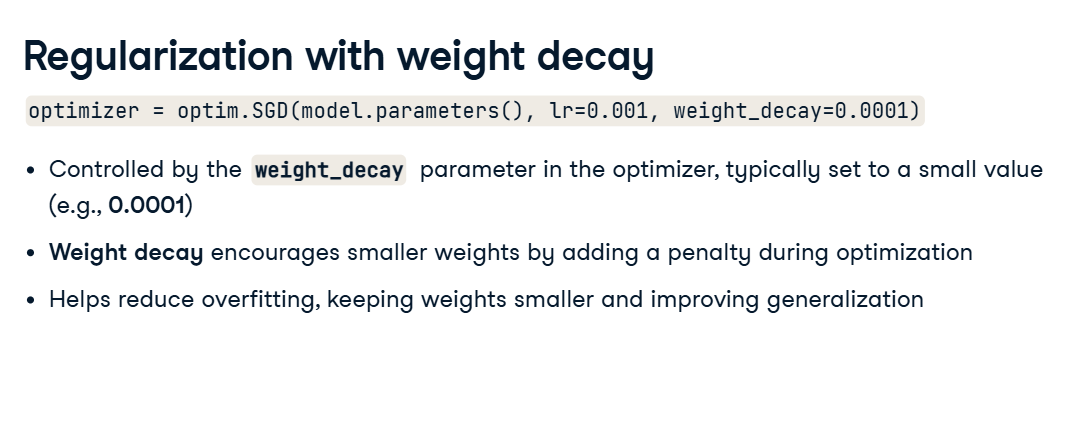

# DROPOUTS , WEIGHT DECAY , BATCH NORM

In [ ]:
# BatchNorm1d?
# 1d → for tabular / fully connected data
# 2d → for images (CNNs)
# 3d → for sequences

# Linear → BatchNorm → Activation

# as convert to model.eval() :droputs stops

In [40]:
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
    nn.Linear(8, 12),
    nn.BatchNorm1d(12),   # 👈 added BatchNorm
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(12, 4),
    nn.BatchNorm1d(4),    # 👈 added BatchNorm
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(4, 1)
)
optimizer = optim.Adam(model.parameters() , lr=0.001, weight_decay =0.001)

In [22]:
y1.value_counts().index.shape[0]

3

In [ ]:

torch.__version__

In [ ]:
torch.cuda.is_available() # False cz our run-time kernel in note book is cpu not gpu
if torch.cuda.is_available():
  print(torch.cuda.get_device_name(0)) # prints available gpu name example here Tesla T4


# CREATING TENSORS IN PYTORCH

In [ ]:
torch.empty(2,2)
# torch.empty() => allocates memory of a given shape tensor and place the the intial values of  those locations which have been allocated to tensor

In [ ]:
torch.zeros(2,2)# zeros tensor

In [ ]:
torch.ones(2,2) # ones tensor

In [ ]:
torch.rand(2,2) # random values

In [ ]:
torch.manual_seed(100)
torch.rand(2,2)

In [ ]:
# custom tensor values
torch.tensor([[1,2,3],[4,5,6]])


In [ ]:
torch.full((2,2),50) # just like numpy

In [ ]:
torch.eye(4) # creatis identity matrix

# RANDOM NUMBERS
 -  names and working are same as numpy

In [ ]:
torch.rand(2,2) # from normal dist

In [ ]:
torch.randn(2,2) # from uniform dist

In [ ]:
torch.randint(0,100,(2,2)) # just like numpy

In [ ]:
torch.linspace(1,10,5) # just like numpy

# SHAPE AND MANUPULATION

In [ ]:
torch.randn(4,4).reshape(2,8) # reshape

In [ ]:
torch.randn(4,4).T # transpose

In [ ]:
torch.concat([torch.eye(4) , torch.randn(4,4)],dim=1) # dim =0 : columns , dim =1  : row
# same as numpy

# Math operations

In [ ]:
tensor = torch.randint(1,99,(4,4))
tensor.max()
tensor.min()
tensor.sum(dim=1) # alongs row
tensor.sum(dim=0) # alongs col
torch.sqrt(tensor)
torch.exp(tensor)

# TENSOR SHAPES


In [ ]:
torch.randint(0,100,(8,8)).ravel() # flatten the array

In [ ]:
tensor = torch.randint(0,100,(8,8))
tensor.shape

#*_like

 -  something_like(x) →
Create a new tensor with the same shape as x.

In [ ]:
# *_like functions in PyTorch (like zeros_like, ones_like, etc.) 👍

# These create a new tensor with the same shape (and usually same dtype & device) as an existing tensor.

In [ ]:
torch.empty_like(tensor)

In [ ]:
torch.zeros_like(tensor)

In [ ]:
torch.ones_like(tensor)

In [ ]:
tensor.dtype # int
# tensor.rand # float between 0-1
torch.rand_like(tensor , dtype=torch.float32) # error cz tensir type is int and rand type is float so use dtype =float


# 🔹 What is an In-Place Operation?

  - An in-place operation modifies the original tensor directly, instead of creating a new one.

-  In PyTorch, in-place operations usually end with:_ (underscore)

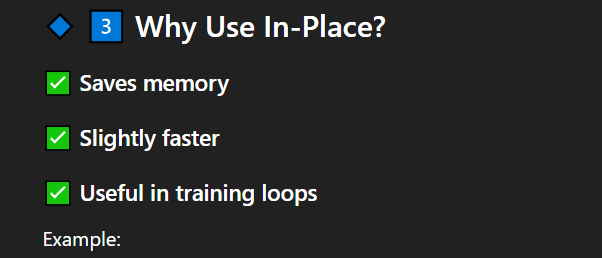

In [ ]:
tensorA = torch.eye(5)
tensorB= torch.ones(5)
tensorA.add_(tensorB)# inplace , stores in tensor A


In [ ]:
tensorA.relu_() # stores in back tensor A

In [ ]:
tensorA.sigmoid_() # inplace sigmoid

# Data Types

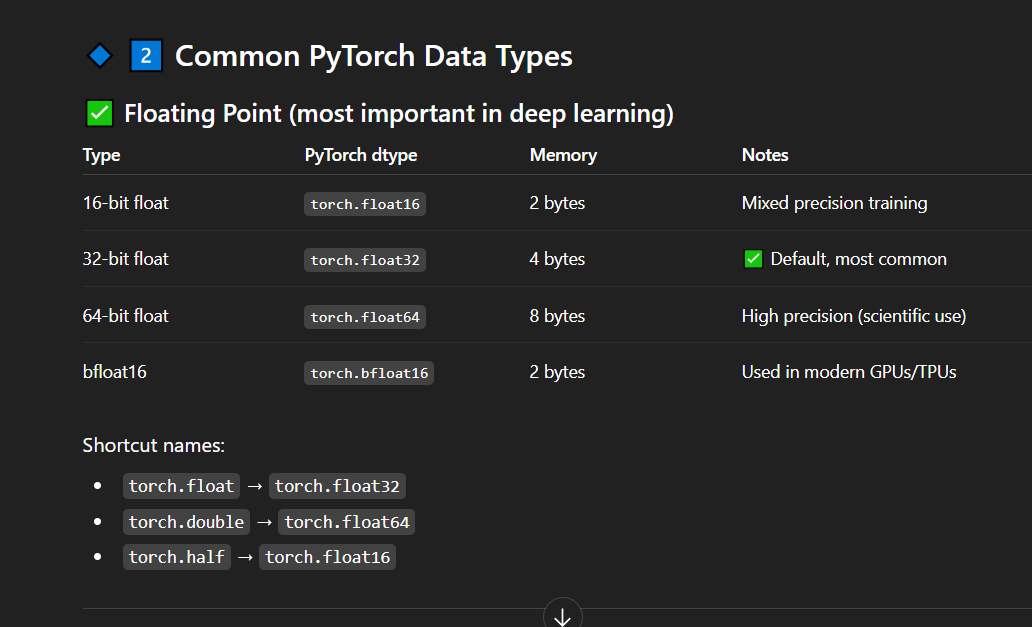

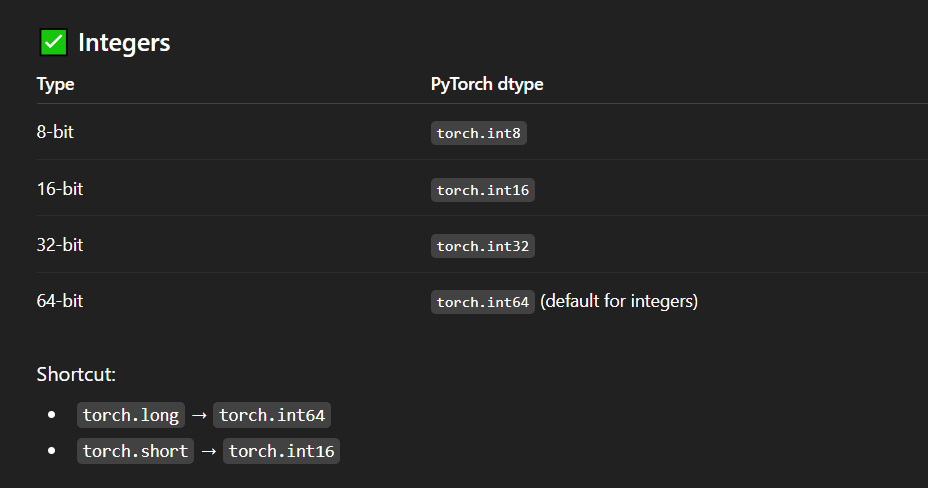

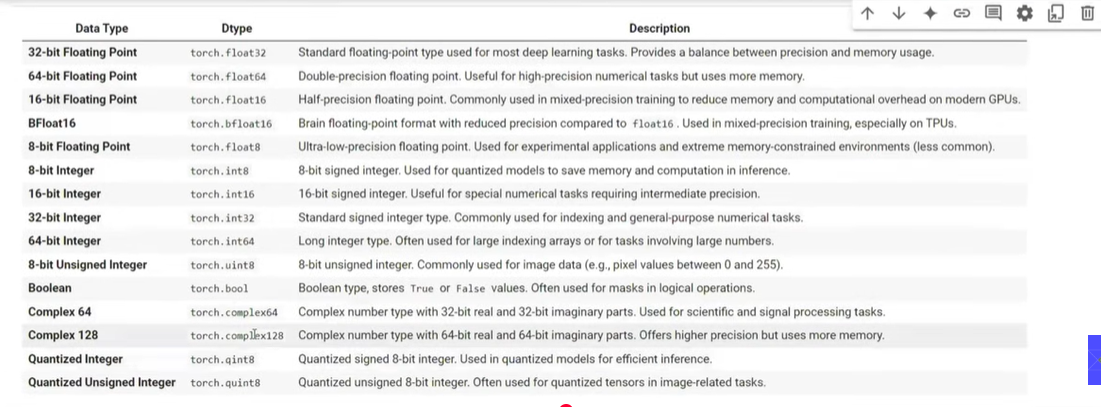

In [ ]:
tensor.to(dtype=torch.float32)

# Copying Tensor

In [ ]:
a =torch.eye(3)
b= torch.clone(a)


In [ ]:
print("id of tensor a ",id(a))
print("id of tensor b ",id(b))

# Tensor operations on GPU

In [ ]:
torch.cuda.is_available()

In [ ]:
torch.cuda.get_device_name()

In [ ]:
device = torch.device("cuda")


In [ ]:
# creating tensor on gpu
torch.rand(2,3 , device=device)

In [ ]:
# moving cpu tensors to gpu
a = torch.randint(1,100,(3,3))
print("inital device :",a.device)  # cpu defualt
k = a.to("cuda") # converted to gpu
print("to gpu : " , k.device)

In [ ]:
a = torch.eye(2 , device="cuda")
b = torch.ones(2 )

# Important Rule: Devices Must Match

- This will cause error:

In [ ]:
a.add(b) # error :Expected all tensors to be on the same device

In [ ]:
torch.randint(1,100,(2,2)).numpy() # coonveritng torch tensor to numpy